In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class DiscretizedRetinotopy(nn.Module):
    def __init__(self, source_grid, out_shape, kernel_size=7, sigma=1.0):
        super().__init__()
        self.kernel_size = kernel_size
        self.sigma = sigma

        source_grid = source_grid - source_grid.mean(axis=0, keepdims=True)
        source_grid = source_grid / np.abs(source_grid).max()
        self.register_buffer("source_grid", torch.from_numpy(source_grid.astype(np.float32)))
        
        n, h, w = out_shape
        self.weights = torch.nn.Parameter(
            torch.normal(mean=torch.ones(2, 1, h, w), std=torch.ones(2, 1, h, w))
        )
        self.bias = torch.nn.Parameter(
            torch.zeros((1, 1, h, w))
            # torch.normal(mean=torch.ones(1, 1, h, w), std=torch.ones(1, 1, h, w))
        )
        
    @property
    def gaussian_kernel(self):
        x = torch.arange(self.kernel_size) - self.kernel_size // 2
        xx, yy = torch.meshgrid(x, x, indexing="ij")
        kernel = torch.exp(-(xx**2 + yy**2) / (2 * self.sigma**2))
        kernel /= kernel.sum()
        return kernel.view(1, 1, self.kernel_size, self.kernel_size)

    def forward(self, pupil_center=None):
        d, _, h, w = self.weights.shape
        
        kernel = self.gaussian_kernel.to(self.source_grid.device)
        smooth_w = F.conv2d(self.weights, kernel, padding='same').view(d, h, w)
        smooth_b = F.conv2d(self.bias, kernel, padding='same').view(1, h, w)
        x = torch.einsum('nd,dhw->nhw', self.source_grid, smooth_w) 
        x = x + smooth_b
        return x, smooth_w, smooth_b

In [3]:
x = np.linspace(-1, 1, 50)
y = np.linspace(-1, 1, 50)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx.flatten(), yy.flatten()], axis=1)

In [4]:
d = DiscretizedRetinotopy(grid, (grid.shape[0], 28, 56), kernel_size=7, sigma=2.0)

In [5]:
x, w, b = d()
x = x.detach()
w = w.detach()
b = b.detach()

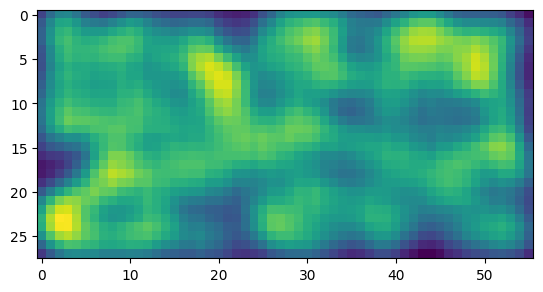

In [19]:
plt.imshow(w[0])

In [213]:
def real_fourier_basis(H, W, max_freq, diagonal):
    y = torch.arange(H)
    x = torch.arange(W)
    Y, X = torch.meshgrid(y, x, indexing="ij")

    basis = []
    for u in range(-max_freq, max_freq + 1):
        for v in range(-max_freq, max_freq + 1):
            phase = 2 * torch.pi * (
                u * Y  + v * X 
            ) / max(H, W)

            # also get rid of cosine for 0, 0 as we use softmax which is logit shift invariant
            if u == 0 and v == 0:
                continue
            if (not diagonal) and u != 0 and v != 0:
                continue

            basis.append(torch.cos(phase))
            basis.append(torch.sin(phase))

    basis = torch.stack(basis)
    mask = torch.zeros(basis.shape[0], dtype=bool)
    for i in range(basis.shape[0]):
        repeat = (basis[i, None] == basis[mask]).all(dim=(1, 2)).any()
        inverse = (basis[i, None] == -basis[mask]).all(dim=(1, 2)).any()

        if not repeat and not inverse:
            mask[i] = True
    return basis[mask]

In [327]:
H, W = 28, 56
y = torch.arange(H)
x = torch.arange(W)
Y, X = torch.meshgrid(y, x, indexing="ij")

basis = []
n = 4
for i in torch.linspace(0, max(H, W), steps=n+1)[:-1]:
    print(i)
    xphase = torch.pi * (2 * X + i) / max(H, W)
    yphase = torch.pi * (2 * Y + i) / max(H, W)

    basis.append(torch.cos(xphase))
    basis.append(torch.cos(yphase))

basis = torch.stack(basis)
mask = torch.zeros(basis.shape[0], dtype=bool)
for i in range(basis.shape[0]):
    repeat = (basis[i, None] == basis[mask]).all(dim=(1, 2)).any()
    inverse = (basis[i, None] == -basis[mask]).all(dim=(1, 2)).any()

    if not repeat and not inverse:
        mask[i] = True

tensor(0.)
tensor(14.)
tensor(28.)
tensor(42.)


In [328]:
basis.shape

torch.Size([8, 28, 56])

In [326]:
H, W = 28, 56
basis = real_fourier_basis(H, W, max_freq=3, diagonal=False)
print(basis.shape)

torch.Size([12, 28, 56])


In [329]:
i=0

In [338]:
plt.imshow(basis[i])
# print(i, freqs[i])
i += 1

IndexError: index 8 is out of bounds for dimension 0 with size 8

In [426]:
dic = {'a': 2, 'b': 3}

In [427]:
del dic['a']

In [51]:
dict2 = dic.copy()

NameError: name 'dic' is not defined

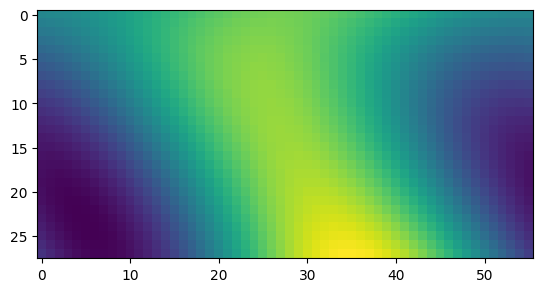

In [ ]:
import math

logits = ((torch.randn(basis.shape[0])[:, None, None]) * (basis + 1) / 2).sum(0)
logits = logits / math.sqrt(basis.shape[0])
plt.imshow(logits)

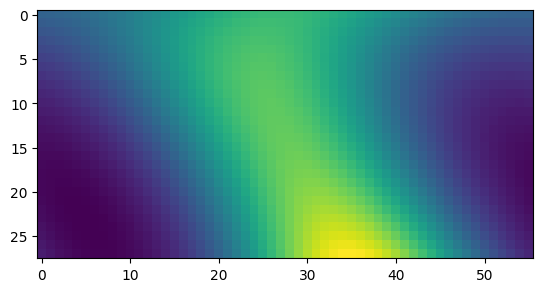

In [84]:
spatial = torch.nn.functional.softmax(logits.view(-1), dim=0).view(H, W)
plt.imshow(spatial)

In [ ]:
n = 1

for i in range(1, n + 1):
    

In [19]:
import torch

def polynomial_basis(x, degree=3, include_bias=False):
    """
    Generate polynomial basis features for 2 inputs.

    Args:
        x: Tensor of shape (N, 2) -- N samples, 2 input dims (x1, x2)
        degree: max total polynomial degree
        include_bias: whether to include the constant term (1)

    Returns:
        Tensor of shape (N, num_terms) with polynomial features
        exponents: list of (i, j) tuples corresponding to each output column
    """
    assert x.shape[1] == 2, "Expected input of shape (N, 2)"
    x1, x2 = x[:, 0], x[:, 1]

    # generate all (i, j) exponent pairs with i + j <= degree
    exponents = []
    for d in range(0 if include_bias else 1, degree + 1):
        for i in range(d + 1):
            j = d - i
            exponents.append((i, j))

    features = torch.stack(
        [(x1 ** i) * (x2 ** j) for (i, j) in exponents], dim=1
    )
    return features, exponents


x = torch.tensor([[1.0, 2.0],
                    [3.0, 4.0],
                    [0.5, -1.0]])

feats, exps = polynomial_basis(x, degree=3)
print("Exponents (i, j):", exps)
print("Features shape:", feats.shape)
print(feats)

Exponents (i, j): [(0, 1), (1, 0), (0, 2), (1, 1), (2, 0), (0, 3), (1, 2), (2, 1), (3, 0)]
Features shape: torch.Size([3, 9])
tensor([[ 2.0000,  1.0000,  4.0000,  2.0000,  1.0000,  8.0000,  4.0000,  2.0000,
          1.0000],
        [ 4.0000,  3.0000, 16.0000, 12.0000,  9.0000, 64.0000, 48.0000, 36.0000,
         27.0000],
        [-1.0000,  0.5000,  1.0000, -0.5000,  0.2500, -1.0000,  0.5000, -0.2500,
          0.1250]])


In [23]:
import torch
import math

def fourier_basis(x, num_frequencies=4, include_bias=True, max_total_freq=None):
    """
    Generate a Fourier basis for 2 inputs (x1, x2).

    Features are of the form:
        cos(2*pi*(k1*x1 + k2*x2)), sin(2*pi*(k1*x1 + k2*x2))
    for integer frequency pairs (k1, k2), excluding (0,0) unless include_bias.

    Args:
        x: Tensor of shape (N, 2)
        num_frequencies: max frequency index per dimension (k ranges over -F..F)
        include_bias: whether to include the constant (1) term
        max_total_freq: optional cap on |k1| + |k2| (like polynomial degree cutoff)

    Returns:
        features: Tensor of shape (N, num_terms)
        freqs: list of (k1, k2) tuples corresponding to each frequency pair
               (note: each non-zero pair contributes 2 columns: cos, sin)
    """
    assert x.shape[1] == 2, "Expected input of shape (N, 2)"
    x1, x2 = x[:, 0], x[:, 1]

    F = num_frequencies
    freq_pairs = []
    for k1 in range(-F, F + 1):
        for k2 in range(-F, F + 1):
            if k1 == 0 and k2 == 0:
                continue
            if max_total_freq is not None and (abs(k1) + abs(k2)) > max_total_freq:
                continue
            # avoid duplicate conjugate-symmetric pairs (k and -k give same cos, sin differs by sign)
            if (k1 < 0) or (k1 == 0 and k2 < 0):
                continue
            freq_pairs.append((k1, k2))

    feature_list = []
    if include_bias:
        feature_list.append(torch.ones_like(x1))

    for (k1, k2) in freq_pairs:
        phase = 2 * math.pi * (k1 * x1 + k2 * x2)
        feature_list.append(torch.cos(phase))
        feature_list.append(torch.sin(phase))

    features = torch.stack(feature_list, dim=1)
    return features, freq_pairs

x = torch.tensor([[0.1, 0.2],
                    [0.3, 0.4],
                    [0.5, 0.9]])

feats, freqs = fourier_basis(x, num_frequencies=2, include_bias=False)
print("Frequency pairs (k1, k2):", freqs)
print("Features shape:", feats.shape)
print(feats)

Frequency pairs (k1, k2): [(0, 1), (0, 2), (1, -2), (1, -1), (1, 0), (1, 1), (1, 2), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2)]
Features shape: torch.Size([3, 24])
tensor([[ 3.0902e-01,  9.5106e-01, -8.0902e-01,  5.8779e-01, -3.0902e-01,
         -9.5106e-01,  8.0902e-01, -5.8779e-01,  8.0902e-01,  5.8779e-01,
         -3.0902e-01,  9.5106e-01, -1.0000e+00, -8.7423e-08,  3.0902e-01,
         -9.5106e-01,  1.0000e+00,  0.0000e+00,  3.0902e-01,  9.5106e-01,
         -8.0902e-01,  5.8779e-01, -8.0902e-01, -5.8779e-01],
        [-8.0902e-01,  5.8779e-01,  3.0902e-01, -9.5106e-01, -1.0000e+00,
          8.7423e-08,  8.0902e-01, -5.8779e-01, -3.0902e-01,  9.5106e-01,
         -3.0902e-01, -9.5106e-01,  8.0902e-01,  5.8779e-01,  3.0902e-01,
         -9.5106e-01,  3.0902e-01,  9.5106e-01, -8.0902e-01, -5.8779e-01,
          1.0000e+00,  1.7485e-07, -8.0902e-01,  5.8778e-01],
        [ 8.0902e-01, -5.8779e-01,  3.0902e-01, -9.5106e-01, -3.0902e-01,
         -9.5106e-01, -8.0902e-01, -5.8779e-01,